## Part 5: Integration, Scaling and Merging

### Integration

Integration refers to accumulating photon counts on a three-dimensional reciprocal space grid. For the tutorial, a grid was chosen with 4 subdivisions in each direction, meaning voxels will be centered at Miller indices h = 1, 1.25, 1.5, 1.75, etc.  This is by no means the optimal choice: the limit depends on the mosaicity, experimental geometry, and most importantly on how the diffuse scattering map will be used. However, when experimenting with different choices for the subdivisions, be aware that finer maps require more memory and disk space.

In [1]:
!mdx2.integrate geometry.nxs data.nxs --mask mask.nxs --subdivide 4 4 4

Reading miller_index from geometry.nxs
  importing as MillerIndex from mdx2.geometry
Reading image_series from data.nxs
patching virtual field: /entry/image_series/data
  importing as ImageSeries from mdx2.data
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    1.1s
[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:    4.5s
[Parallel(n_jobs=1)]: Done   7 tasks      | elapsed:    7.9s
[Parallel(n_jobs=1)]: Done  12 tasks      | elapsed:   13.3s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:   19.1s
[Parallel(n_jobs=1)]: Done  24 tasks      | elapsed:   27.3s
[Parallel(n_jobs=1)]: Done  31 tasks      | elapsed:   35.0s
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:   45.8s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   56.3s
[Parallel(n_jobs=1)]: Done  60 tasks      | elapsed:  1.2min
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:  1.3min
[Parallel(n_jobs=1)]: Done  84 tasks      | elapsed:  1.5min
[Parallel(n_jobs=1)]: Done  97 tasks      | elapsed:  1.7

For each voxel, the integrated photon counts and other data used in corrections are stored in a table in `integrated.nxs`. After integration, the pre-computed geometric and background corrections are applied:

In [2]:
!mdx2.correct geometry.nxs integrated.nxs --background bkg_data_binned.nxs

Reading hkl_table from integrated.nxs
  importing as HKLTable from mdx2.data
Reading corrections from geometry.nxs
  importing as Corrections from mdx2.geometry
Reading crystal from geometry.nxs
  importing as Crystal from mdx2.geometry
Reading symmetry from geometry.nxs
  importing as Symmetry from mdx2.geometry
calculating scattering vector magnitude (s)
mapping Miller indices to the asymmetric unit
Reading binned_image_series from bkg_data_binned.nxs
  importing as GridData from mdx2.geometry
subtracting background from count rate
correctin solid angle for attenuation
correcting solid angle for efficiency
correcting solid angle for polarization
computing the swept reciprocal space volume fraction (rs_volume)
computing intensity and intensity_error
Exporting <class 'mdx2.data.HKLTable'> to nexus object
  writing hkl_table to corrected.nxs
done!


The corrected intensities are saved as a table in `corrected.nxs`. The following Python code can be used to load the table as a _pandas_ dataframe and preview the first several lines:

In [3]:
from mdx2.utils import loadobj

# load the table
tab = loadobj('corrected.nxs','hkl_table')

# convert to pandas dataframe
df = tab.to_frame().set_index(['h','k','l','op','n'])

# show the first several lines
df.head()

intensity  intensity_error           ix           iy  \
h    k     l    op n                                                          
5.00 17.50 65.0 5  0  16793666.0       14677456.0  2457.466553  2525.666748   
     17.25 65.0 5  0  41120612.0        9574618.0  2459.753662  2521.579590   
     17.00 65.0 5  0  57043060.0       16950380.0  2461.379395  2515.275879   
5.25 17.50 65.0 5  0  76086376.0       59900372.0  2457.000000  2526.000000   
     17.25 65.0 5  0  31622778.0        8051682.0  2459.696289  2522.721436   

                             phi  rs_volume         s  
h    k     l    op n                                   
5.00 17.50 65.0 5  0  209.889999   0.000944  0.848811  
     17.25 65.0 5  0  209.884781   0.004339  0.848001  
     17.00 65.0 5  0  209.887924   0.001823  0.847203  
5.25 17.50 65.0 5  0  209.683334   0.000189  0.849050  
     17.25 65.0 5  0  209.647461   0.004967  0.848240

The columns contain the following information:

- `h`, `k`, `l`: Miller indices mapped to the _asymmetric unit_
- `op`: index of the symmetry operator that mapped the observation point to the asymmetric unit
- `s`: scattering vector magnitude (= 1/resolution)
- `intensity`, `intensity_error`: measured intensities and errors corrected for geometric effects and background scattering.
- `rs_volume`: volume of reciprocal space recorded as a fraction of the reciprocal unit cell. Here, a voxel that is fully recorded during would have `rs_volume` = 4<sup>-3</sup> ~ 0.0156.

### Scaling

Finally, the corrected intensities can be scaled and merged. The default scaling model includes a scale factor _b_ that can vary continuously during the scan. Refine _b_ as follows:

In [4]:
!mdx2.scale corrected.nxs

Reading hkl_table from corrected.nxs
  importing as HKLTable from mdx2.data
loaded 15286815 reflections from 1 files
Grouping redundant observations
masked 387044 singletons (reflections with only one observation)
starting main scaling refinement
optimizing scale vs. phi (b)
  iteration 1 of 10
    applying scale factors
    merging
    fitting the model
    current x2: 1.3674527188046026
  iteration 2 of 10
    applying scale factors
    merging
    fitting the model
    current x2: 1.0341035588208107
  iteration 3 of 10
    applying scale factors
    merging
    fitting the model
    current x2: 1.0113563729791755
  iteration 4 of 10
    applying scale factors
    merging
    fitting the model
    current x2: 1.0097427429640897
  iteration 5 of 10
    applying scale factors
    merging
    fitting the model
    current x2: 1.009624629081865
  iteration 6 of 10
    applying scale factors
    merging
    fitting the model
    current x2: 1.0096158355850378
    change in x2 less than to

The model is refined using regularization to ensure that the correction factors vary gradually. An optional parameter `--alpha.alpha` sets the relative weight for minimizing smoothness vs. 𝜒^2^.  The default value of 1 is a good starting point, but it can be varied up or down to observe the effect (e.g. by factors of 10). Additional optional parameters are available to further define the scaling model and refinement procedure (see `mdx2.scale --help`). By default, 10 cycles of alternating least-squares are performed and the scaling model is written to the file `scales.nxs`.

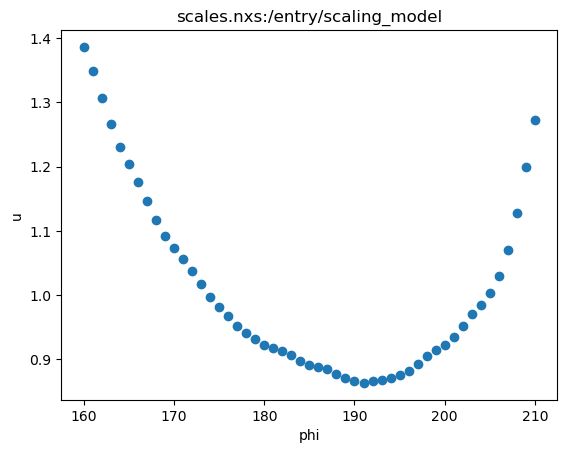

In [5]:
from nexusformat.nexus import nxload
scales = nxload('scales.nxs','r')['/entry/scaling_model']
scales.plot()

### Merging

After scaling, the equivalent observations can be merged. The following produces the file `merged.nxs` that includes a table of intensities and error estimates.

In [6]:
!mdx2.merge corrected.nxs --scale scales.nxs

Reading hkl_table from corrected.nxs
  importing as HKLTable from mdx2.data
Grouping redundant observations
Reading scaling_model from scales.nxs
  importing as ScalingModel from mdx2.scaling
applying scale factors
merging
Exporting <class 'mdx2.data.HKLTable'> to nexus object
  writing hkl_table to merged.nxs
done!
